# 第二部分：函数拟合

使用两层 ReLU 神经网络拟合自定义函数，并验证万能近似能力。

## 一、函数定义

定义目标函数 $y = f(x)$。本例采用：

$$f(x) = \sin(x) + 0.3 \cos(2x), \quad x \in [-\pi, \pi]$$

该函数在有限区间上连续，适合用两层 ReLU 网络近似。

In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 目标函数: f(x) = sin(x) + 0.3*cos(2x)
def target_function(x):
    """在区间 [-pi, pi] 上定义的目标函数。"""
    return np.sin(x) + 0.3 * np.cos(2 * x)

## 二、数据采集

- **训练集**：在 $[-\pi, \pi]$ 上均匀采样 500 个点，并加入少量高斯噪声。
- **测试集**：在相同区间上均匀采样 200 个点（无噪声），用于评估拟合效果。

In [8]:
# 采样参数
np.random.seed(42)
train_size = 500
test_size = 200
x_min, x_max = -np.pi, np.pi
noise_std = 0.05  # 训练标签噪声标准差

# 训练集：均匀采样 + 高斯噪声
x_train = np.linspace(x_min, x_max, train_size).astype(np.float32).reshape(-1, 1)
y_train = target_function(x_train) + np.random.normal(0, noise_std, size=x_train.shape).astype(np.float32)

# 测试集：均匀采样，无噪声
x_test = np.linspace(x_min, x_max, test_size).astype(np.float32).reshape(-1, 1)
y_test = target_function(x_test).astype(np.float32)

print('Train samples:', x_train.shape[0])
print('Test samples:', x_test.shape[0])

Train samples: 500
Test samples: 200


## 三、模型描述

- **结构**：两层全连接（一层隐藏 + 一层输出）：输入 → 64 维 ReLU 隐藏层 → 1 维输出（回归）。
- **损失**：均方误差 (MSE)。
- **优化器**：Adam，学习率 0.01。

In [9]:
# 构建两层 ReLU 网络: 输入(1) -> 隐藏层(64, ReLU) -> 输出(1)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 训练
history = model.fit(
    x_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=0
)

# 最终指标
train_loss = model.evaluate(x_train, y_train, verbose=0)
test_loss = model.evaluate(x_test, y_test, verbose=0)
print('Train MSE:', round(train_loss[0], 6), ', MAE:', round(train_loss[1], 6))
print('Test MSE:', round(test_loss[0], 6), ', MAE:', round(test_loss[1], 6))

Train MSE: 0.003236 , MAE: 0.043603
Test MSE: 0.001033 , MAE: 0.021694


## 四、拟合效果

绘制真实曲线与网络预测曲线，并给出测试集误差。

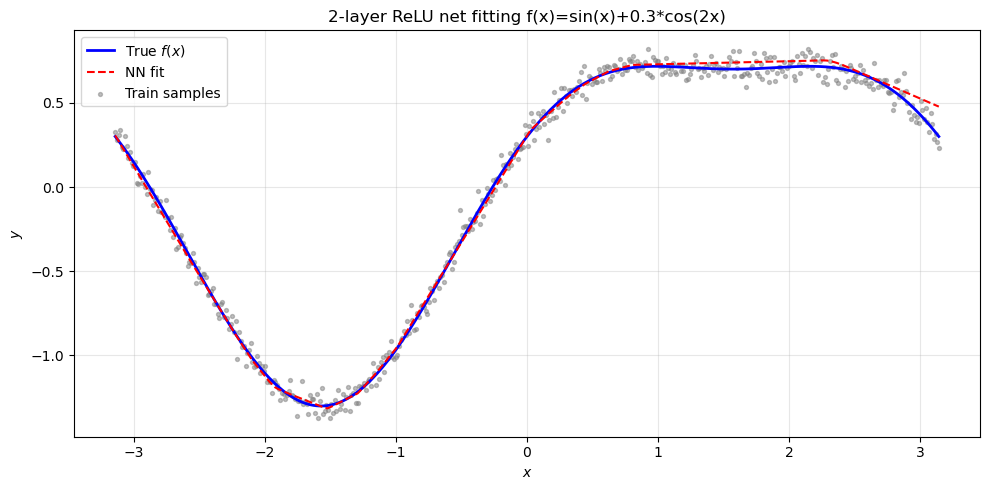

In [11]:
# 在密集点上预测，用于平滑绘图
x_plot = np.linspace(x_min, x_max, 300).astype(np.float32).reshape(-1, 1)
y_true = target_function(x_plot)
y_pred = model.predict(x_plot, verbose=0)

plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_true, 'b-', label=r'True $f(x)$', linewidth=2)
plt.plot(x_plot, y_pred, 'r--', label='NN fit', linewidth=1.5)
plt.scatter(x_train, y_train, s=8, alpha=0.5, c='gray', label='Train samples')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.title('2-layer ReLU net fitting f(x)=sin(x)+0.3*cos(2x)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

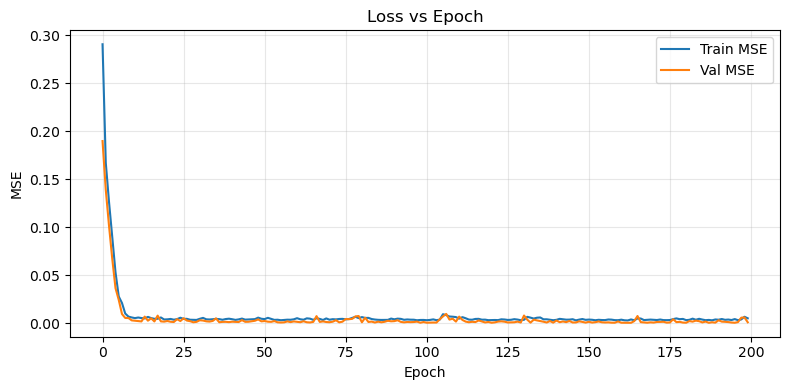

In [12]:
# 训练过程 loss 曲线
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('Loss vs Epoch')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()